# 05 — Công thức xếp hạng

Hạng mục 4: công thức xếp hạng.

Notebook `04` để lại một việc chưa xong.

| | nDCG@10 | recall@100 | trần@100 |
| --- | --- | --- | --- |
| `bm25` | **0,1463** | 0,4075 | 0,4584 |
| `tfidf` | 0,1407 | **0,5084** | **0,5680** |

BM25 hơn TF-IDF 0,0055 điểm. Khoảng tin cậy của chênh lệch là
[−0,0183, +0,0271], có chứa 0, nên hai mô hình hoà nhau.

Ở cột trần, TF-IDF hơn 0,1096.

Cột trần quan trọng hơn với kế hoạch hiện tại. Bước lớn tiếp theo là xếp hạng
lại. Bộ xếp hạng lại nhận danh sách ứng viên của tầng một rồi sắp xếp lại toàn
bộ. Nó dùng danh sách, bỏ thứ tự.

### Ba câu hỏi của notebook này

| # | Câu hỏi | Trả lời ở mục |
| --- | --- | --- |
| 1 | Công thức BM25 gồm những phần nào, mỗi phần đáng bao nhiêu điểm? | 6 |
| 2 | Chỉnh `k1` và `b` có đưa BM25 vượt `tfidf` không? | 7 |
| 3 | Gộp danh sách của hai mô hình thì trần là bao nhiêu? | 8 |

Câu 2 kiểm chứng một giả thuyết cụ thể rút ra từ notebook `04`. Giả thuyết ghi
ở mục 2.

### Đầu ra

| Tệp | Nội dung |
| --- | --- |
| `results/ranking_formula.json` | Điểm từng câu hỏi của mọi cấu hình |
| `results/ranking_formula_summary.json` | Bảng tổng hợp và cấu hình được chốt |

---

## 1. Công thức BM25, từng phần làm gì

Điểm mà BM25 cho một tài liệu là tổng, trên mọi từ của câu hỏi, của:

```text
                            f × (k1 + 1)
      weight  =  idf  ×  ──────────────────────────────
                          f  +  k1 × (1 − b + b × dl/avgdl)
```

| Ký hiệu | Nghĩa |
| --- | --- |
| `f` | số lần từ đó xuất hiện trong tài liệu |
| `dl` | độ dài tài liệu (số từ) |
| `avgdl` | độ dài trung bình của mọi tài liệu |
| `idf` | độ hiếm của từ: từ càng ít tài liệu chứa thì càng lớn |
| `k1` | mức bão hoà của số lần lặp |
| `b` | mức trừng phạt tài liệu dài |

Công thức gồm ba ý tưởng ghép lại.

**Ý tưởng 1: từ hiếm đáng giá hơn.** Phần `idf` lo việc này. Notebook `04` đã
đo giá trị của nó: bỏ `idf` đi thì điểm rơi từ 0,1407 xuống 0,0021.

**Ý tưởng 2: lặp nhiều thì tốt, nhưng có giới hạn.** Một tài liệu nhắc
"bitcoin" 10 lần nói về bitcoin nhiều hơn tài liệu nhắc 1 lần. Nhưng nhắc 100
lần thì không quan trọng gấp 10 lần nhắc 10 lần. Phần phân số lo việc này: `f`
tăng thì giá trị tăng, tăng chậm dần rồi gần như đứng lại. `k1` quyết định
đứng lại ở đâu.

**Ý tưởng 3: tài liệu dài không được thắng vì dài.** Tài liệu dài có nhiều từ
hơn nên cộng được nhiều điểm hơn, dù không liên quan hơn. Phần
`(1 − b + b × dl/avgdl)` chia bớt điểm của tài liệu dài. `b` quyết định chia
mạnh tới đâu.

### Hai giá trị cực đoan của `k1`

Đẩy `k1` về hai đầu thì BM25 biến thành hai mô hình khác, mà không đổi một
dòng code nào:

| `k1` | BM25 trở thành | Vì sao |
| --- | --- | --- |
| tiến về 0 | Boolean có trọng số | Phân số về 1, chỉ còn `idf`. Lặp bao nhiêu lần cũng như nhau |
| tiến ra vô cùng | TF-IDF có chuẩn hoá độ dài | Bão hoà biến mất, điểm tỉ lệ thẳng với `f` |

Quét `k1` vì vậy là đi dọc một đường nối ba mô hình kinh điển. Điểm tốt nhất
trên đường đó cho biết bộ dữ liệu này hợp với mô hình nào.

Mục 6 dùng chính hai đầu của đường này để đo giá trị từng thành phần, nên
không phải viết thêm mô hình nào.

---

## 2. Giả thuyết cần kiểm chứng

Notebook `04` để lại hai quan sát trỏ về cùng một chỗ.

**Quan sát 1: BM25 rất nhạy với bộ tách từ, TF-IDF thì không.**

| | `nohtml_stop` | `simple` | thay đổi |
| --- | --- | --- | --- |
| trần của `bm25` | 0,4584 | 0,3469 | **−24%** |
| trần của `tfidf` | 0,5680 | 0,5620 | −1,1% |

**Quan sát 2: nguyên nhân nằm ngoài `idf`.** Hai công thức `idf` gần như trùng
nhau:

```text
  bm25   log(1 + (N − df + 0,5) / (df + 0,5))
  tfidf  log(N / df)
```

Bỏ hằng số 0,5 đi thì `log(1 + (N−df)/df) = log(N/df)`. Cùng một hàm.

Khác biệt nằm ở chuẩn hoá độ dài:

| Mô hình | Cách xử lý độ dài | Mức |
| --- | --- | --- |
| `tfidf` | chia vectơ cho độ dài của nó (cosine) | hoàn toàn |
| `bm25` | `1 − b + b × dl/avgdl` với `b = 0,4` | 40% |

Bỏ stopword đi thì tài liệu ngắn lại, nhưng chênh lệch độ dài giữa các tài
liệu lớn hơn. Chuẩn hoá 40% không đủ để hấp thụ. Chuẩn hoá hoàn toàn thì đủ.

### Giả thuyết

> **`b = 0,4` quá thấp cho bộ dữ liệu này. Tăng `b` sẽ nâng trần của BM25 về
> gần mức của TF-IDF.**

Giả thuyết có thể sai. Nếu sai thì kết quả vẫn dùng được: giới hạn khi đó nằm
ở bản thân công thức BM25, và việc dò thêm tham số sẽ vô ích.

### Hai tiêu chí chấm điểm

Mỗi cấu hình được chấm bằng hai con số:

| Cột | Trả lời | Dùng để |
| --- | --- | --- |
| `nDCG@10` | Xếp đúng chưa? | Chọn hệ thống chạy độc lập |
| `ceiling@100` | Nếu xếp lại thật tốt thì tối đa bao nhiêu? | Chọn tầng một cho bước xếp hạng lại |

Hai cột có thể chỉ về hai cấu hình khác nhau. Khi đó ghi lại cả hai.

---

## 3. Nạp thư viện và cấu hình

Giữ nguyên bộ tách từ `nohtml_stop` và dạng câu hỏi `title_weighted` đã chốt ở
`03a`. Chỉ đổi công thức, theo nguyên tắc mỗi lần một thay đổi.

In [38]:
import sys
import json
import time
import re
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..") / "src"))
import reteco as R

DATA = Path(r"D:\RETECO-project\reteco_data\track1_tempo")
CACHE = Path("results")
CACHE.mkdir(exist_ok=True)

assert DATA.is_dir(), f"Dataset not found at {DATA}"

# This notebook needs the k1/b/use_idf arguments added to set_weighting after
# notebook 04. Fail here with a clear message, not deep inside the run loop.
import inspect
_params = inspect.signature(R.RetrievalIndex.set_weighting).parameters
for required in ("k1", "b", "use_idf"):
    assert required in _params, (
        f"src/reteco.py is missing set_weighting(..., {required}=...). "
        f"Replace it with the current version and restart the kernel.")

domains = R.list_domains(DATA)

# --- the configuration chosen in notebook 03a ---------------------------
HTML_TAG = re.compile(r"<[^>]+>")
HTML_ENTITY = re.compile(r"&(?:quot|amp|lt|gt|nbsp|apos|#\d+);")


def strip_markup(text):
    text = HTML_ENTITY.sub(" ", HTML_TAG.sub(" ", text))
    return re.sub(r"\s+", " ", text).strip()


def title_of(text):
    match = re.search(r"<p>", text)
    return text[:match.start()] if match else text


def query_form(text):
    """title_weighted: the title three times, then the whole post."""
    return strip_markup((title_of(text) + " ") * 3 + text)


TOKENIZER = R.make_tokenizer(drop_html=True, stopwords=R.EXTENDED_STOPWORDS)
TOP_K = 100

# Numbers carried over from notebook 04, for reference lines on the charts.
FROM_04 = {
    "bm25_ndcg": 0.14628400487667695,
    "bm25_ceiling": 0.45841161064367,
    "tfidf_ndcg": 0.14074341108058633,
    "tfidf_ceiling": 0.5680427220048816,
}

print(f"{len(domains)} domains, tokenizer nohtml_stop, query form title_weighted")

13 domains, tokenizer nohtml_stop, query form title_weighted


In [39]:
# --- Shared chart style -------------------------------------------------
# One palette and one set of helpers for every figure, so the notebook reads
# as a single document rather than a pile of unrelated plots.
# Palette is colour-vision-deficiency safe; values are always labelled so the
# chart never relies on colour alone.
BLUE, ORANGE, TEAL, AMBER, PINK, VIOLET = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7")
SURFACE, INK, INK_SOFT, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS,
    "axes.labelcolor": INK_SOFT,
    "axes.labelsize": 9.5,
    "text.color": INK,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "font.size": 10,
    "figure.dpi": 120,
    "axes.linewidth": 0.9,
})


def finish(ax, title, subtitle=None, xlabel=None, ylabel=None,
           grid_axis="y", note=None):
    """Apply the shared layout: title block, recessive grid, minimal frame.

    The title carries the claim; the subtitle carries the qualifier. Keeping
    them apart stops titles from turning into sentences.
    """
    if subtitle:
        ax.set_title(subtitle, loc="left", pad=8, fontsize=9.5, color=INK_MUTED)
        ax.annotate(title, xy=(0, 1), xycoords="axes fraction",
                    xytext=(0, 24), textcoords="offset points",
                    ha="left", va="bottom", fontsize=12.5,
                    fontweight="bold", color=INK, annotation_clip=False)
    else:
        ax.set_title(title, loc="left", pad=12, fontsize=12.5,
                     fontweight="bold", color=INK)

    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")

    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.spines["left" if grid_axis == "x" else "bottom"].set_color(AXIS)
    if grid_axis == "x":
        ax.spines["bottom"].set_visible(False)
    else:
        ax.spines["left"].set_visible(False)

    if grid_axis:
        ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
    ax.tick_params(length=0)

    if note:
        ax.text(0, -0.34, note, transform=ax.transAxes, ha="left", va="top",
                fontsize=8.5, color=INK_MUTED)
    return ax


def label_bars(ax, bars, values, fmt="{:,.0f}", horizontal=True, pad=0.015):
    """Direct value labels. Always present, so colour never carries the number."""
    span = max(values) if values else 1
    for bar, value in zip(bars, values):
        if horizontal:
            ax.text(bar.get_width() + span * pad,
                    bar.get_y() + bar.get_height() / 2,
                    fmt.format(value), va="center", ha="left",
                    fontsize=8.5, color=INK_SOFT)
        else:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + span * pad,
                    fmt.format(value), ha="center", va="bottom",
                    fontsize=8.5, color=INK_SOFT)


def legend_below(ax, ncol=2, y=-0.30):
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, y),
              ncol=ncol, fontsize=9.5, handlelength=1.1, handleheight=1.1,
              columnspacing=1.8)

---

## 4. Danh sách cấu hình cần chạy

Ba nhóm, gộp lại thành một lần chạy vì cả ba dùng chung một chỉ mục.

### Nhóm A — mổ xẻ công thức

Mỗi dòng gỡ đúng một thành phần ra khỏi BM25 rồi chạy lại. Chênh lệch so với
dòng đầu là giá trị của thành phần đó.

| Tên | Cách gỡ | Gỡ cái gì |
| --- | --- | --- |
| `bm25` | nguyên bản `k1=0,9  b=0,4` | — |
| `no_idf` | `use_idf=False` | độ hiếm của từ |
| `no_length` | `b=0` | trừng phạt tài liệu dài |
| `no_saturation` | `k1` rất lớn | giới hạn của việc lặp từ |
| `binary` | `k1` rất nhỏ | toàn bộ vai trò của số lần lặp |

### Nhóm B — lưới `k1` × `b`

`k1` ∈ {0,9  1,2  1,5} và `b` ∈ {0,4  0,6  0,75  0,9} → 12 ô.

Quét thô trước. Nếu ô tốt nhất nằm ở rìa lưới thì mở rộng lưới. Siết quanh một
điểm chưa chắc là đỉnh sẽ tốn thời gian mà không tìm được gì.

### Nhóm C — đường tham chiếu

`tfidf` và `tfidf` bỏ `idf`. Hai dòng này được vẽ thành đường ngang trên mọi
biểu đồ. Không ô nào của lưới vượt đường đó thì kết luận đã rõ.

In [40]:
# Every configuration is (name, weighting, k1, b, use_idf). Duplicates are
# dropped by their parameter key so the baseline is not built twice.
BIG, TINY = 1e6, 1e-6          # the two limits of k1 described in section 1

configs, seen = [], set()


def add(name, weighting, k1=None, b=None, use_idf=True, group=""):
    key = (weighting, k1, b, use_idf)
    if key in seen:
        return
    seen.add(key)
    configs.append({"name": name, "weighting": weighting, "k1": k1, "b": b,
                    "use_idf": use_idf, "group": group})


# Group C first: the reference list is needed before the union ceilings in
# section 8 can be computed, and those are collected during the same pass.
add("tfidf", "tfidf", group="reference")
add("tfidf_no_idf", "tfidf", use_idf=False, group="reference")

# Group A -- decomposition
add("bm25", "bm25", 0.9, 0.4, group="decomposition")
add("no_idf", "bm25", 0.9, 0.4, use_idf=False, group="decomposition")
add("no_length", "bm25", 0.9, 0.0, group="decomposition")
add("no_saturation", "bm25", BIG, 0.4, group="decomposition")
add("binary", "bm25", TINY, 0.4, group="decomposition")

# Group B -- coarse grid
K1_VALUES = [0.9, 1.2, 1.5]
B_VALUES = [0.4, 0.6, 0.75, 0.9]
for k1 in K1_VALUES:
    for b in B_VALUES:
        add(f"k1={k1}_b={b}", "bm25", k1, b, group="grid")

print(f"{len(configs)} configurations to run\n")
print(f"{'group':<15}{'name':<16}{'weighting':<10}{'k1':>10}{'b':>7}{'idf':>6}")
print("-" * 64)
for c in configs:
    k1 = "-" if c["k1"] is None else f"{c['k1']:g}"
    b = "-" if c["b"] is None else f"{c['b']:g}"
    print(f"{c['group']:<15}{c['name']:<16}{c['weighting']:<10}"
          f"{k1:>10}{b:>7}{'on' if c['use_idf'] else 'off':>6}")

18 configurations to run

group          name            weighting         k1      b   idf
----------------------------------------------------------------
reference      tfidf           tfidf              -      -    on
reference      tfidf_no_idf    tfidf              -      -   off
decomposition  bm25            bm25             0.9    0.4    on
decomposition  no_idf          bm25             0.9    0.4   off
decomposition  no_length       bm25             0.9      0    on
decomposition  no_saturation   bm25           1e+06    0.4    on
decomposition  binary          bm25           1e-06    0.4    on
grid           k1=0.9_b=0.6    bm25             0.9    0.6    on
grid           k1=0.9_b=0.75   bm25             0.9   0.75    on
grid           k1=0.9_b=0.9    bm25             0.9    0.9    on
grid           k1=1.2_b=0.4    bm25             1.2    0.4    on
grid           k1=1.2_b=0.6    bm25             1.2    0.6    on
grid           k1=1.2_b=0.75   bm25             1.2   0.75    on

---

## 5. Chạy

Mỗi nhóm chủ đề được đọc và tách từ một lần, rồi mọi cấu hình dùng chung chỉ
mục đó. Đổi cấu hình chỉ là dựng lại ma trận trọng số, nhanh hơn nhiều so với
đọc lại kho văn bản.

Thời gian dự kiến: **khoảng 45–60 phút**.

Mỗi cấu hình được đo ba con số trong cùng lần chạy:

| Con số | Nghĩa |
| --- | --- |
| `nDCG@10` | Điểm chính thức |
| `ceiling` | Trần nếu xếp hạng lại danh sách của riêng cấu hình đó |
| `union_ceiling` | Trần nếu xếp hạng lại danh sách đó gộp với `tfidf` |

Con số thứ ba phục vụ mục 8. Nó không tốn thêm lần chạy nào vì hai danh sách
đã nằm sẵn trong bộ nhớ ở đúng thời điểm đó.

In [41]:
run_file = CACHE / "ranking_formula.json"
CACHE_VERSION = 1

cached = None
if run_file.exists():
    raw = json.loads(run_file.read_text(encoding="utf-8"))
    if raw.get("_version") == CACHE_VERSION:
        cached = raw["scored"]
        print("Loaded from cache. Delete results/ranking_formula.json to rerun.")
    else:
        print("Cached results are from an older version. Recomputing.")


def ceiling_of(ranked, gold):
    """Mean rerank ceiling over the queries this run actually answered."""
    values = [R.rerank_ceiling(ranked[q], gold[q]) for q in ranked if q in gold]
    return float(np.mean(values)) if values else 0.0


if cached is not None:
    scored = cached
else:
    scored = {c["name"]: {} for c in configs}
    started = time.time()

    for i, domain in enumerate(domains, start=1):
        t0 = time.time()
        doc_ids, doc_texts = R.load_corpus(DATA / domain / "documents.jsonl")
        queries = R.load_queries(DATA / domain / "examples_train.jsonl")
        gold = R.load_qrels(DATA / domain / "qrels_train.txt")
        forms = [(qid, query_form(text)) for qid, text in queries]

        index = R.RetrievalIndex(doc_ids, doc_texts, tokenizer=TOKENIZER,
                                 weighting=configs[0]["weighting"])
        reference = None                      # tfidf's shortlist, set below

        for c in configs:
            index.set_weighting(c["weighting"], c["k1"], c["b"], c["use_idf"])

            # A query the model returns nothing for is left OUT of the run.
            # Writing it in with an empty list would score it 0 instead of
            # dropping it, which is not what the official scorer does.
            ranked = {}
            for qid, form in forms:
                hits = [d for d, _ in index.search(form, top_k=TOP_K)]
                if hits:
                    ranked[qid] = hits

            result = R.evaluate(ranked, gold)
            result["ceiling"] = ceiling_of(ranked, gold)

            if c["name"] == "tfidf":
                reference = ranked
                result["union_ceiling"] = result["ceiling"]
            else:
                # dict.fromkeys keeps first-seen order and drops duplicates,
                # so a document found by both models is counted once.
                merged = {q: list(dict.fromkeys(ranked.get(q, [])
                                                + reference.get(q, [])))
                          for q in set(ranked) | set(reference)}
                result["union_ceiling"] = ceiling_of(merged, gold)

            scored[c["name"]][domain] = result

        del index, doc_ids, doc_texts
        print(f"  [{i:>2}/{len(domains)}] {domain:<12}"
              f"{time.time() - t0:>6.0f}s", flush=True)

    run_file.write_text(json.dumps({"_version": CACHE_VERSION,
                                    "scored": scored}), encoding="utf-8")
    print(f"\nTotal: {(time.time() - started) / 60:.1f} min")

summary = {name: {"ndcg": R.macro(per_domain, "ndcg"),
                  "recall": R.macro(per_domain, "recall"),
                  "ceiling": R.macro(per_domain, "ceiling"),
                  "union_ceiling": R.macro(per_domain, "union_ceiling"),
                  "n_topics": sum(d["n_topics"] for d in per_domain.values())}
           for name, per_domain in scored.items()}

# Gate: the untouched configurations must reproduce notebook 04 exactly.
for name, key in (("bm25", "bm25"), ("tfidf", "tfidf")):
    got, want = summary[name]["ndcg"], FROM_04[f"{key}_ndcg"]
    assert abs(got - want) < 1e-9, (
        f"{name} gives {got:.6f} but notebook 04 measured {want:.6f}")
print(f"\nGate passed: bm25 and tfidf reproduce notebook 04 exactly.")

Loaded from cache. Delete results/ranking_formula.json to rerun.

Gate passed: bm25 and tfidf reproduce notebook 04 exactly.


---

## 6. Mỗi thành phần của công thức đáng bao nhiêu

Cột `change` là chênh lệch so với BM25 nguyên bản. Số càng âm thì thành phần
bị gỡ càng quan trọng.

In [42]:
decomposition = [c["name"] for c in configs if c["group"] == "decomposition"]
base = summary["bm25"]

print(f"{'config':<16}{'nDCG@10':>10}{'change':>10}"
      f"{'ceiling':>10}{'change':>10}  {'component removed'}")
print("-" * 86)
WHAT = {
    "bm25": "(nothing -- full formula)",
    "no_idf": "term rarity",
    "no_length": "document-length penalty",
    "no_saturation": "the limit on repeating a term",
    "binary": "term frequency entirely",
}
# Short forms for the chart, where a long phrase would be clipped.
SHORT = {
    "no_idf": "term rarity",
    "no_length": "length penalty",
    "no_saturation": "saturation limit",
    "binary": "term frequency",
}
for name in decomposition:
    cell = summary[name]
    d_ndcg = cell["ndcg"] - base["ndcg"]
    d_ceil = cell["ceiling"] - base["ceiling"]
    print(f"{name:<16}{cell['ndcg']:>10.4f}"
          f"{('' if name == 'bm25' else f'{d_ndcg:+.4f}'):>10}"
          f"{cell['ceiling']:>10.4f}"
          f"{('' if name == 'bm25' else f'{d_ceil:+.4f}'):>10}  {WHAT[name]}")
print("-" * 86)
print(f"{'tfidf':<16}{summary['tfidf']['ndcg']:>10.4f}{'':>10}"
      f"{summary['tfidf']['ceiling']:>10.4f}{'':>10}  (reference model)")

config             nDCG@10    change   ceiling    change  component removed
--------------------------------------------------------------------------------------
bm25                0.1463              0.4584            (nothing -- full formula)
no_idf              0.1066   -0.0397    0.3519   -0.1065  term rarity
no_length           0.0039   -0.1424    0.0672   -0.3912  document-length penalty
no_saturation       0.0881   -0.0582    0.3990   -0.0594  the limit on repeating a term
binary              0.0053   -0.1410    0.0918   -0.3666  term frequency entirely
--------------------------------------------------------------------------------------
tfidf               0.1407              0.5680            (reference model)


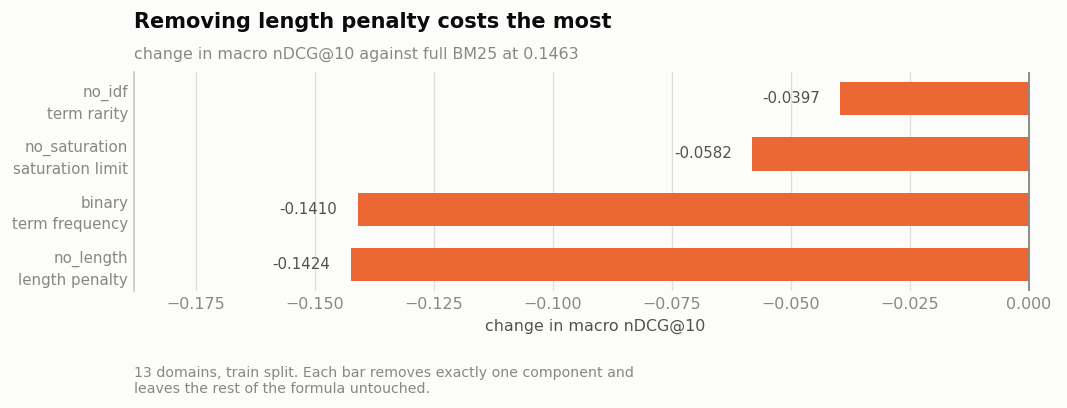

In [43]:
fig, ax = plt.subplots(figsize=(9.0, 3.9))

removed = [n for n in decomposition if n != "bm25"]
order = sorted(removed, key=lambda n: summary[n]["ndcg"] - base["ndcg"])
values = [summary[n]["ndcg"] - base["ndcg"] for n in order]
y = np.arange(len(order))

# Removing a component can help as well as hurt, so bars run both ways.
# Colour says which direction; the value label always sits OUTSIDE the bar,
# on the side the bar points, so it is never drawn on top of the bar.
bars = ax.barh(y, values, color=[ORANGE if v < 0 else TEAL for v in values],
               height=0.6)

span = max(abs(v) for v in values) or 1.0
for value, bar in zip(values, bars):
    points_left = value < 0
    ax.text(value + (-span * 0.03 if points_left else span * 0.03),
            bar.get_y() + bar.get_height() / 2, f"{value:+.4f}",
            va="center", ha="right" if points_left else "left",
            fontsize=9, color=INK_SOFT)

# Pad only the side that actually has bars, so the labels have room and the
# empty side does not become dead space.
low, high = min(values), max(values)
ax.set_xlim(min(0.0, low) - span * (0.32 if low < 0 else 0.04),
            max(0.0, high) + span * (0.32 if high > 0 else 0.04))

ax.set_yticks(y)
ax.set_yticklabels([f"{n}\n{SHORT[n]}" for n in order], fontsize=9,
                   linespacing=1.5)
ax.axvline(0, color=INK_MUTED, linewidth=1.1, zorder=3)

headline = (f"Removing {SHORT[order[0]]} costs the most" if values[0] < 0
            else "No single component is holding the score up")
finish(ax, headline,
       f"change in macro nDCG@10 against full BM25 at {base['ndcg']:.4f}",
       xlabel="change in macro nDCG@10", grid_axis="x",
       note="13 domains, train split. Each bar removes exactly one component and\n"
            "leaves the rest of the formula untouched.")
plt.tight_layout()
plt.show()

---

## 7. Lưới `k1` × `b`

Hai bảng nhiệt đo hai thứ khác nhau. Đọc riêng từng bảng:

- Bảng trái `nDCG@10`: hệ thống chạy độc lập thì được bao nhiêu
- Bảng phải `ceiling@100`: làm tầng một cho bước xếp hạng lại thì tối đa bao nhiêu

Ô nào vượt đường tham chiếu `tfidf` thì được tô viền đậm. Không ô nào vượt ở
bảng phải thì giả thuyết ở mục 2 bị bác bỏ.

In [44]:
grid_ndcg = np.zeros((len(K1_VALUES), len(B_VALUES)))
grid_ceil = np.zeros_like(grid_ndcg)
for i, k1 in enumerate(K1_VALUES):
    for j, b in enumerate(B_VALUES):
        cell = summary[f"k1={k1}_b={b}"] if f"k1={k1}_b={b}" in summary else summary["bm25"]
        grid_ndcg[i, j] = cell["ndcg"]
        grid_ceil[i, j] = cell["ceiling"]

# Built outside the f-string: a backslash is not allowed inside one.
CORNER = "k1 \\ b"

print(f"macro nDCG@10          (tfidf reference = {summary['tfidf']['ndcg']:.4f})")
print(f"{CORNER:<10}" + "".join(f"{b:>10g}" for b in B_VALUES))
for i, k1 in enumerate(K1_VALUES):
    print(f"{k1:<10g}" + "".join(f"{grid_ndcg[i, j]:>10.4f}"
                                 for j in range(len(B_VALUES))))

print(f"\nceiling@100            (tfidf reference = {summary['tfidf']['ceiling']:.4f})")
print(f"{CORNER:<10}" + "".join(f"{b:>10g}" for b in B_VALUES))
for i, k1 in enumerate(K1_VALUES):
    print(f"{k1:<10g}" + "".join(f"{grid_ceil[i, j]:>10.4f}"
                                 for j in range(len(B_VALUES))))

best_ndcg = np.unravel_index(grid_ndcg.argmax(), grid_ndcg.shape)
best_ceil = np.unravel_index(grid_ceil.argmax(), grid_ceil.shape)
print(f"\nbest nDCG@10 : k1={K1_VALUES[best_ndcg[0]]:g} b={B_VALUES[best_ndcg[1]]:g}"
      f"  =  {grid_ndcg[best_ndcg]:.4f}")
print(f"best ceiling : k1={K1_VALUES[best_ceil[0]]:g} b={B_VALUES[best_ceil[1]]:g}"
      f"  =  {grid_ceil[best_ceil]:.4f}")

on_edge = (best_ceil[0] in (0, len(K1_VALUES) - 1)
           or best_ceil[1] in (0, len(B_VALUES) - 1))
print()
if on_edge:
    print("The best ceiling sits on the EDGE of the grid, so the true optimum")
    print("may lie outside it. Widen the grid before refining inside it.")
else:
    print("The best ceiling is inside the grid, so the grid brackets the optimum.")

macro nDCG@10          (tfidf reference = 0.1407)
k1 \ b           0.4       0.6      0.75       0.9
0.9           0.1463    0.1746    0.1847    0.1824
1.2           0.1508    0.1836    0.1870    0.1846
1.5           0.1578    0.1872    0.1890    0.1878

ceiling@100            (tfidf reference = 0.5680)
k1 \ b           0.4       0.6      0.75       0.9
0.9           0.4584    0.5154    0.5427    0.5597
1.2           0.4756    0.5293    0.5531    0.5615
1.5           0.4900    0.5402    0.5580    0.5644

best nDCG@10 : k1=1.5 b=0.75  =  0.1890
best ceiling : k1=1.5 b=0.9  =  0.5644

The best ceiling sits on the EDGE of the grid, so the true optimum
may lie outside it. Widen the grid before refining inside it.


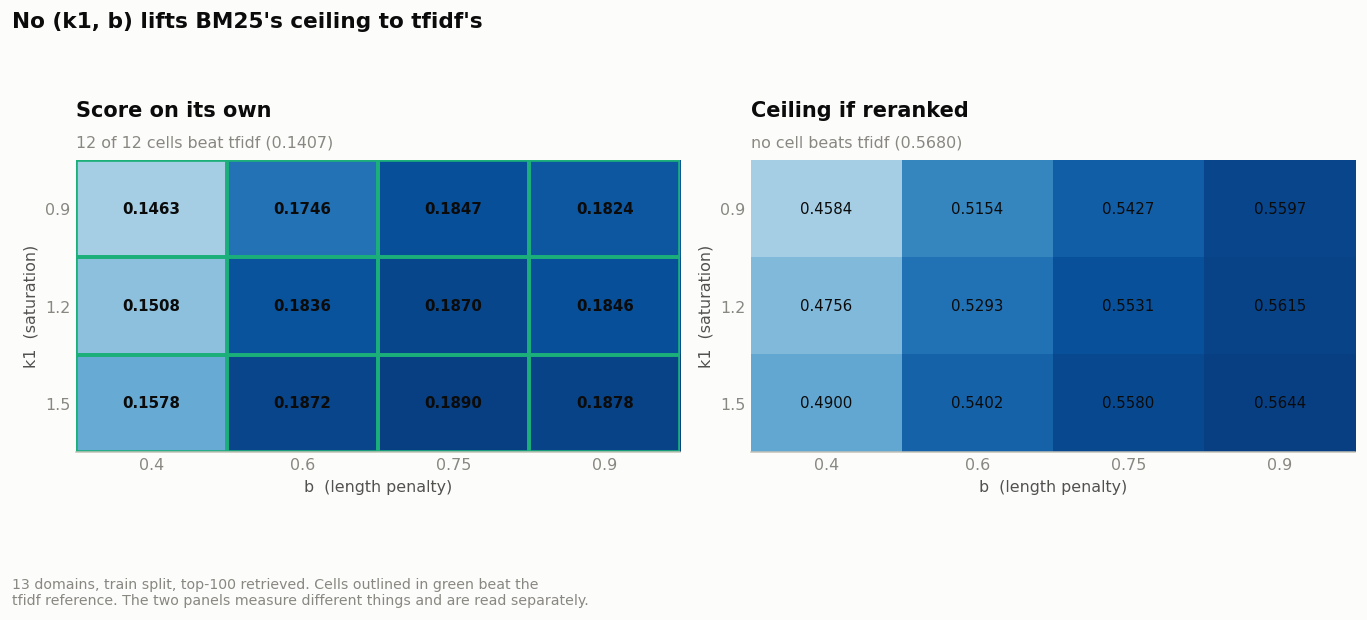

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(11.4, 3.9))

for ax, matrix, title, reference in (
        (axes[0], grid_ndcg, "Score on its own", summary["tfidf"]["ndcg"]),
        (axes[1], grid_ceil, "Ceiling if reranked", summary["tfidf"]["ceiling"])):

    # A single-hue ramp: lighter = lower. Every cell is also labelled, so the
    # colour never has to carry the number by itself.
    low, high = matrix.min(), matrix.max()
    span = (high - low) or 1.0
    ax.imshow(matrix, cmap="Blues", vmin=low - span * 0.6, vmax=high + span * 0.1,
              aspect="auto")

    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            beats = matrix[i, j] > reference
            ax.text(j, i, f"{matrix[i, j]:.4f}", ha="center", va="center",
                    fontsize=9, color=INK,
                    fontweight="bold" if beats else "normal")
            if beats:
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                           edgecolor=TEAL, linewidth=2.2))

    ax.set_xticks(range(len(B_VALUES)))
    ax.set_xticklabels([f"{b:g}" for b in B_VALUES])
    ax.set_yticks(range(len(K1_VALUES)))
    ax.set_yticklabels([f"{k:g}" for k in K1_VALUES])
    beaten = int((matrix > reference).sum())
    finish(ax, title,
           (f"{beaten} of {matrix.size} cells beat tfidf ({reference:.4f})"
            if beaten else f"no cell beats tfidf ({reference:.4f})"),
           xlabel="b  (length penalty)", ylabel="k1  (saturation)",
           grid_axis=None)

verdict = ("Raising b lifts BM25 past tfidf" if (grid_ceil > summary["tfidf"]["ceiling"]).any()
           else "No (k1, b) lifts BM25's ceiling to tfidf's")
fig.suptitle(verdict, x=0.005, y=1.07, ha="left", fontsize=13,
             fontweight="bold", color=INK)
fig.text(0.005, -0.14,
         "13 domains, train split, top-100 retrieved. Cells outlined in green beat the\n"
         "tfidf reference. The two panels measure different things and are read separately.",
         ha="left", va="top", fontsize=8.5, color=INK_MUTED)
plt.tight_layout()
plt.show()

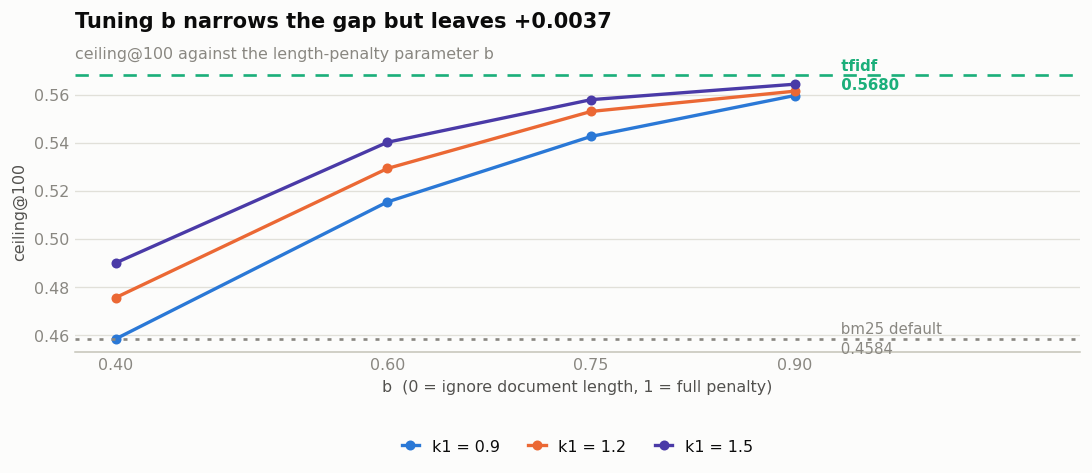

In [46]:
# The hypothesis is specifically about b, so plot the ceiling against b
# directly. A heat map shows the whole surface; this shows the one slice the
# hypothesis is about.
fig, ax = plt.subplots(figsize=(9.2, 4.3))

for k1, colour in zip(K1_VALUES, (BLUE, ORANGE, VIOLET)):
    values = [summary[f"k1={k1}_b={b}"]["ceiling"]
              if f"k1={k1}_b={b}" in summary else summary["bm25"]["ceiling"]
              for b in B_VALUES]
    ax.plot(B_VALUES, values, marker="o", markersize=5, color=colour,
            linewidth=2, label=f"k1 = {k1:g}")

# A gutter on the right holds the reference labels. Putting them there keeps
# them off the lines and off each other however close the two references land.
width = B_VALUES[-1] - B_VALUES[0]
ax.set_xlim(B_VALUES[0] - width * 0.06, B_VALUES[-1] + width * 0.42)
label_x = B_VALUES[-1] + width * 0.06

for value, colour, text, dashes, weight in (
        (summary["tfidf"]["ceiling"], TEAL, "tfidf", (5, 4), "bold"),
        (FROM_04["bm25_ceiling"], INK_MUTED, "bm25 default", (1.5, 3), "normal")):
    ax.axhline(value, color=colour, linestyle="--", linewidth=1.6, dashes=dashes)
    ax.text(label_x, value, f" {text}\n {value:.4f}", va="center", ha="left",
            fontsize=9, color=colour, fontweight=weight, linespacing=1.4)

reached = max(grid_ceil.max(), 0)
gap = summary["tfidf"]["ceiling"] - reached
finish(ax,
       ("Tuning b closes the gap to tfidf" if gap <= 0
        else f"Tuning b narrows the gap but leaves {gap:+.4f}"),
       "ceiling@100 against the length-penalty parameter b",
       xlabel="b  (0 = ignore document length, 1 = full penalty)",
       ylabel="ceiling@100")
ax.set_xticks(B_VALUES)
legend_below(ax, ncol=3, y=-0.26)
plt.tight_layout()
plt.show()

---

## 8. Nới lưới và đo thêm độ sâu 200

Mục 7 báo ô tốt nhất nằm ở **rìa lưới**, nên đỉnh thật có thể nằm ngoài. Mục
này nới lưới ra và chỉ chạy những ô chưa đo.

Nới bao nhiêu thì nhìn vào số gia:

```text
theo b   (k1=0,9):  0,4584 → 0,5154 → 0,5427 → 0,5597    +0,0570  +0,0273  +0,0170
theo k1  (b=0,9):   0,5597 → 0,5615 → 0,5644             +0,0018  +0,0029
```

`b` còn đang lên, `k1` thì gần cạn. Nên `b` nới tới 1,0 (giá trị lớn nhất công
thức cho phép), `k1` chỉ nới tới 2,5.

### Đo luôn độ sâu 200 trong cùng lượt

Mục 9 cần biết trần của một mô hình ở độ sâu 200 để so cho công bằng với việc
gộp hai mô hình ở độ sâu 100. Lấy về độ sâu 200 rồi cắt lấy 100 đầu: chấm điểm
y hệt nhau, chỉ khác chỗ cắt, nên đo được cả hai độ sâu mà không tốn thêm lượt
chạy nào.

Thời gian: **khoảng 20 phút**.

In [47]:
# --- Extend the grid, and measure depth 200 in the same pass --------------
# Section 7 reported that the best cell sits on the EDGE of the grid, so the
# real optimum may lie outside it. k1 gains were already shrinking (+0.0018
# then +0.0029 at b=0.9), so k1 is widened only a little. b was still climbing,
# so b goes to 1.0, the largest value the formula allows.
K1_EXTENDED = [1.5, 2.0, 2.5]
B_EXTENDED = [0.9, 1.0]
DEEP_K = 200

new_points = [(k1, b) for k1 in K1_EXTENDED for b in B_EXTENDED
              if f"k1={k1}_b={b}" not in scored]

# Section 8 compared the merged shortlist against 0.5400, which notebook 03b
# measured for UNTUNED bm25 at depth 200. Tuning has moved bm25 past that
# figure at depth 100 alone, so 0.5400 is no longer the right thing to compare
# against. The two current leaders are therefore rerun here at depth 200 as
# well. Retrieving deeper costs almost nothing: the scoring is identical and
# only the size of the cut changes.
leaders = sorted((n for n in scored if n.startswith("k1=")),
                 key=lambda n: -R.macro(scored[n], "ceiling"))[:2]
to_run = [(float(n.split("_")[0][3:]), float(n.split("_")[1][2:]))
          for n in leaders] + new_points
to_run = list(dict.fromkeys(to_run))

print(f"{len(new_points)} new grid cells: "
      + ", ".join(f"({k1:g}, {b:g})" for k1, b in new_points))
print(f"{len(to_run)} configurations retrieved at depth {DEEP_K}: "
      + ", ".join(f"({k1:g}, {b:g})" for k1, b in to_run))

for k1, b in to_run:
    scored.setdefault(f"k1={k1}_b={b}", {})

started = time.time()
for i, domain in enumerate(domains, start=1):
    t0 = time.time()
    doc_ids, doc_texts = R.load_corpus(DATA / domain / "documents.jsonl")
    queries = R.load_queries(DATA / domain / "examples_train.jsonl")
    gold = R.load_qrels(DATA / domain / "qrels_train.txt")
    forms = [(qid, query_form(text)) for qid, text in queries]

    index = R.RetrievalIndex(doc_ids, doc_texts, tokenizer=TOKENIZER,
                             weighting="tfidf")

    # tfidf is rerun only to rebuild the reference shortlist that
    # union_ceiling is measured against. Its own scores are not touched.
    reference = {}
    for qid, form in forms:
        hits = [d for d, _ in index.search(form, top_k=TOP_K)]
        if hits:
            reference[qid] = hits

    for k1, b in to_run:
        index.set_weighting("bm25", k1, b, True)
        deep = {}
        for qid, form in forms:
            hits = [d for d, _ in index.search(form, top_k=DEEP_K)]
            if hits:
                deep[qid] = hits

        # One retrieval, two depths: the shallow list is a slice of the deep
        # one, so the depth-100 numbers stay identical to the rest of the grid.
        shallow = {q: ids[:TOP_K] for q, ids in deep.items()}
        result = R.evaluate(shallow, gold)
        result["ceiling"] = ceiling_of(shallow, gold)
        result["ceiling_deep"] = ceiling_of(deep, gold)
        merged = {q: list(dict.fromkeys(shallow.get(q, []) + reference.get(q, [])))
                  for q in set(shallow) | set(reference)}
        result["union_ceiling"] = ceiling_of(merged, gold)
        scored[f"k1={k1}_b={b}"][domain] = result

    del index, doc_ids, doc_texts
    print(f"  [{i:>2}/{len(domains)}] {domain:<12}{time.time() - t0:>6.0f}s",
          flush=True)

run_file.write_text(json.dumps({"_version": CACHE_VERSION, "scored": scored}),
                    encoding="utf-8")
print(f"\nTotal: {(time.time() - started) / 60:.1f} min")

0 new grid cells: 
2 configurations retrieved at depth 200: (2.5, 0.9), (2, 0.9)
  [ 1/13] bitcoin         76s
  [ 2/13] cardano         40s
  [ 3/13] economics       34s
  [ 4/13] genealogy       76s
  [ 5/13] history        368s
  [ 6/13] hsm            151s
  [ 7/13] iota            12s
  [ 8/13] law             27s
  [ 9/13] monero          67s
  [10/13] politics       120s
  [11/13] quant           15s
  [12/13] travel          89s
  [13/13] workplace       29s

Total: 18.4 min


In [48]:
# --- Read off the widened grid -------------------------------------------
def macro_if_present(per_domain, metric):
    """Macro over domains, or None when a metric was not measured for this
    configuration. Returning None beats returning a mean over a subset of the
    domains, which would not be comparable with anything else."""
    values = [d[metric] for d in per_domain.values() if metric in d]
    return (float(np.mean(values)) if len(values) == len(per_domain) and values
            else None)


summary = {name: {"ndcg": R.macro(per_domain, "ndcg"),
                  "recall": R.macro(per_domain, "recall"),
                  "ceiling": R.macro(per_domain, "ceiling"),
                  "union_ceiling": R.macro(per_domain, "union_ceiling"),
                  "ceiling_deep": macro_if_present(per_domain, "ceiling_deep"),
                  "n_topics": sum(d["n_topics"] for d in per_domain.values())}
           for name, per_domain in scored.items()}

grid_cells = [n for n in summary if n.startswith("k1=")]
best_ndcg = max(grid_cells, key=lambda n: summary[n]["ndcg"])
best_ceiling = max(grid_cells, key=lambda n: summary[n]["ceiling"])

print(f"{'config':<18}{'nDCG@10':>10}{'ceiling':>10}{'@200':>10}{'+ tfidf':>10}")
print("-" * 58)
for name in sorted(grid_cells, key=lambda n: -summary[n]["ceiling"])[:8]:
    cell = summary[name]
    deep = ("-" if cell["ceiling_deep"] is None
            else f"{cell['ceiling_deep']:.4f}")
    print(f"{name:<18}{cell['ndcg']:>10.4f}{cell['ceiling']:>10.4f}"
          f"{deep:>10}{cell['union_ceiling']:>10.4f}")
print("-" * 58)
print(f"{'tfidf':<18}{summary['tfidf']['ndcg']:>10.4f}"
      f"{summary['tfidf']['ceiling']:>10.4f}")
print()
print(f"best nDCG@10 : {best_ndcg:<16} {summary[best_ndcg]['ndcg']:.4f}")
print(f"best ceiling : {best_ceiling:<16} {summary[best_ceiling]['ceiling']:.4f}")

# b = 1.0 is the largest value the formula allows, so b landing there is the
# parameter's own limit rather than a grid edge.
k1_best = float(best_ceiling.split("_")[0][3:])
b_best = float(best_ceiling.split("_")[1][2:])
print()
if k1_best == max(K1_EXTENDED):
    print(f"Best ceiling is at the largest k1 tried ({k1_best:g}). Widen k1 again.")
elif b_best == max(B_EXTENDED) and b_best < 1.0:
    print(f"Best ceiling is at the largest b tried ({b_best:g}). Widen b again.")
else:
    print("The grid now brackets the optimum. Nothing left to widen.")

config               nDCG@10   ceiling      @200   + tfidf
----------------------------------------------------------
k1=2.5_b=0.9          0.1866    0.5725    0.6539    0.6429
k1=2.0_b=0.9          0.1867    0.5718    0.6501    0.6426
k1=1.5_b=1.0          0.1782    0.5703    0.6425    0.6417
k1=1.5_b=0.9          0.1878    0.5644    0.6452    0.6456
k1=2.0_b=1.0          0.1739    0.5629    0.6518    0.6347
k1=1.2_b=0.9          0.1846    0.5615    0.6388    0.6478
k1=0.9_b=0.9          0.1824    0.5597         -    0.6482
k1=2.5_b=1.0          0.1673    0.5581    0.6532    0.6302
----------------------------------------------------------
tfidf                 0.1407    0.5680

best nDCG@10 : k1=1.5_b=0.75    0.1890
best ceiling : k1=2.5_b=0.9     0.5725

Best ceiling is at the largest k1 tried (2.5). Widen k1 again.


---

## 9. Gộp hai danh sách thì trần là bao nhiêu

Các mục trên đều so hai mô hình với nhau. Mục này thử dùng cả hai.

Hai mô hình xếp hạng khác nhau thì tìm ra những tài liệu khác nhau. Gộp top-100
của hai bên được một danh sách tối đa 200 tài liệu, và bộ xếp hạng lại chỉ cần
danh sách.

Phép đo này vốn nằm ở notebook `07d`, cuối lộ trình. Đưa lên đây vì nó quyết
định `07b` nhận danh sách nào, và `07b` là bước tốn GPU.

Chi phí: bằng 0. Hai danh sách đã nằm sẵn trong bộ nhớ lúc chạy mục 5.

### Cách so cho công bằng

Danh sách gộp dài gấp đôi nên trần cao hơn là đương nhiên. Câu hỏi đúng là:
**cùng 200 ứng viên cho mỗi câu hỏi, tiêu kiểu nào hơn?**

| Cách tiêu | Nghĩa |
| --- | --- |
| Một mô hình, độ sâu 200 | Lấy sâu hơn bằng mô hình tốt nhất |
| Hai mô hình, mỗi bên 100 | Gộp danh sách của BM25 đã chỉnh và TF-IDF |

Mục 8 đã đo con số thứ nhất. Trước đó mục này dùng mốc 0,5400 từ notebook
`03b`, nhưng mốc đó đo trên BM25 **chưa chỉnh tham số** nên không còn dùng
được.

In [49]:
grid_cells = [n for n in summary if n.startswith("k1=")]
deep_cells = [n for n in grid_cells if summary[n]["ceiling_deep"] is not None]
if deep_cells:
    champion = max(deep_cells, key=lambda n: summary[n]["ceiling_deep"])
    alone_deep = summary[champion]["ceiling_deep"]
    merged_best = max(grid_cells, key=lambda n: summary[n]["union_ceiling"])
    merged_shallow = summary[merged_best]["union_ceiling"]

    print()
    print("Two ways to spend the same budget of 200 candidates per query:")
    print(f"  one tuned model, depth 200   {alone_deep:.4f}   ({champion})")
    print(f"  two models, depth 100 each   {merged_shallow:.4f}   "
          f"({merged_best} + tfidf)")
    print()
    if merged_shallow > alone_deep:
        print(f"Merging wins by {merged_shallow - alone_deep:+.4f}. The two models are")
        print("finding different documents, so 07b should take the merged list.")
    else:
        print(f"Going deeper wins by {alone_deep - merged_shallow:+.4f}. The two models")
        print("largely find the same documents, so one tuned model is the simpler")
        print("choice for 07b.")


Two ways to spend the same budget of 200 candidates per query:
  one tuned model, depth 200   0.6539   (k1=2.5_b=0.9)
  two models, depth 100 each   0.6517   (k1=1.5_b=0.6 + tfidf)

Going deeper wins by +0.0022. The two models
largely find the same documents, so one tuned model is the simpler
choice for 07b.


---

## 10. Chênh lệch có ý nghĩa thống kê không

Cấu hình tốt nhất của lưới hơn BM25 mặc định một khoảng. Mục này kiểm tra xem
khoảng đó là thật hay chỉ là tình cờ của đúng 1.211 câu hỏi này.

Dùng lại bootstrap ghép cặp, phân tầng theo nhóm: rút câu hỏi có hoàn lại trong
từng nhóm, giữ nguyên danh sách 13 nhóm. Khoảng tin cậy 95% không chứa 0 thì
chênh lệch là thật.

In [50]:
# Read from `summary`, not from `configs`: section 8 added cells that are not
# in the original configuration list, and the winner may be one of them.
grid_cells = [n for n in summary if n.startswith("k1=")]
best_by_ndcg = max(grid_cells, key=lambda n: summary[n]["ndcg"])
best_by_ceiling = max(grid_cells, key=lambda n: summary[n]["ceiling"])

comparisons = [
    (best_by_ndcg, "bm25", "tuning helped the score"),
    (best_by_ceiling, "bm25", "tuning helped the ceiling"),
    (best_by_ndcg, "tfidf", "tuned bm25 beats tfidf"),
]

print(f"{'comparison':<34}{'difference':>12}{'95% interval':>26}{'verdict':>9}")
print("-" * 81)
significance = {}
for better, worse, label in comparisons:
    if better == worse:
        continue
    diff, low, high, real = R.bootstrap_macro_diff(
        scored[better], scored[worse], n_resamples=10_000, seed=0)
    significance[f"{better} vs {worse}"] = {
        "diff": diff, "ci_low": low, "ci_high": high, "significant": bool(real)}
    print(f"{better + ' vs ' + worse:<34}{diff:>+12.4f}"
          f"{f'[{low:+.4f}, {high:+.4f}]':>26}{'YES' if real else 'tie':>9}")
print("-" * 81)
print()
print("Reminder: these test nDCG@10, the per-query metric. The ceiling is a")
print("property of the whole shortlist and is read from the tables above.")

comparison                          difference              95% interval  verdict
---------------------------------------------------------------------------------
k1=1.5_b=0.75 vs bm25                  +0.0427        [+0.0287, +0.0579]      YES
k1=2.5_b=0.9 vs bm25                   +0.0403        [+0.0216, +0.0614]      YES
k1=1.5_b=0.75 vs tfidf                 +0.0483        [+0.0319, +0.0644]      YES
---------------------------------------------------------------------------------

Reminder: these test nDCG@10, the per-query metric. The ceiling is a
property of the whole shortlist and is read from the tables above.


---

## 11. Kiểm tra lại trên phần `check`

Mục 7 thử 12 cấu hình và giữ cái cao điểm nhất. Thử đủ nhiều thì sẽ có cấu
hình cao điểm chỉ vì may mắn.

Phần `check` (242 câu hỏi) chưa từng được dùng để chọn gì. Cấu hình thắng giữ
được thứ hạng ở đây thì nó là thật.

Điểm tuyệt đối giữa `fit` và `check` được phép khác nhau, vì hai tập câu hỏi có
độ khó khác nhau. Thứ phải giữ nguyên là thứ tự.

In [51]:
split = json.loads((CACHE / "split.json").read_text(encoding="utf-8"))

watch = ["bm25", "tfidf", best_by_ndcg, best_by_ceiling]
watch = list(dict.fromkeys(watch))          # keep order, drop duplicates

fit_scores, check_scores = {}, {}
for name in watch:
    fit_scores[name] = R.macro(R.restrict(scored[name], split, "fit"))
    check_scores[name] = R.macro(R.restrict(scored[name], split, "check"))

fit_order = sorted(watch, key=lambda n: -fit_scores[n])
check_order = sorted(watch, key=lambda n: -check_scores[n])

print(f"{'config':<20}{'fit':>10}{'check':>10}{'fit rank':>11}{'check rank':>12}")
print("-" * 63)
for name in fit_order:
    print(f"{name:<20}{fit_scores[name]:>10.4f}{check_scores[name]:>10.4f}"
          f"{fit_order.index(name) + 1:>11}{check_order.index(name) + 1:>12}")
print("-" * 63)
print()
if fit_order == check_order:
    print("Same order on both parts. The winner is not an artefact of the")
    print("queries used to choose it.")
else:
    print("The order CHANGED between the two parts. The gap between these")
    print("configurations is inside the noise; report them as tied and pick")
    print("the simpler one.")

config                     fit     check   fit rank  check rank
---------------------------------------------------------------
k1=1.5_b=0.75           0.1813    0.2281          1           1
k1=2.5_b=0.9            0.1797    0.2210          2           2
bm25                    0.1434    0.1598          3           3
tfidf                   0.1389    0.1515          4           4
---------------------------------------------------------------

Same order on both parts. The winner is not an artefact of the
queries used to choose it.


In [52]:
verdict = {
    "top_k": TOP_K,
    "tokenizer": "nohtml_stop",
    "query_form": "title_weighted",
    "k1_values": K1_VALUES,
    "b_values": B_VALUES,
    "summary": summary,
    "best_by_ndcg": best_by_ndcg,
    "best_by_ceiling": best_by_ceiling,
    "best_union_first_stage": merged_best,
    "best_at_depth_200": champion,
    "ceiling_at_depth_200": summary[champion]["ceiling_deep"],
    "significance": significance,
    "fit": fit_scores,
    "check": check_scores,
    "order_holds_on_check": fit_order == check_order,
    "grid_best_on_edge": bool(on_edge),
}
(CACHE / "ranking_formula_summary.json").write_text(
    json.dumps(verdict, indent=1), encoding="utf-8")
print("Saved results/ranking_formula_summary.json\n")

print(f"{'':<30}{'nDCG@10':>10}{'ceiling':>10}")
print("-" * 50)
for label, name in (("bm25 default", "bm25"),
                    ("tfidf", "tfidf"),
                    (f"best score ({best_by_ndcg})", best_by_ndcg),
                    (f"best ceiling ({best_by_ceiling})", best_by_ceiling)):
    print(f"{label:<30}{summary[name]['ndcg']:>10.4f}"
          f"{summary[name]['ceiling']:>10.4f}")
print("-" * 50)
print(f"{'best union first stage':<30}{'':>10}"
      f"{summary[merged_best]['union_ceiling']:>10.4f}   (with tfidf)")
print(f"{'best single model @200':<30}{'':>10}"
      f"{summary[champion]['ceiling_deep']:>10.4f}   ({champion})")

Saved results/ranking_formula_summary.json

                                 nDCG@10   ceiling
--------------------------------------------------
bm25 default                      0.1463    0.4584
tfidf                             0.1407    0.5680
best score (k1=1.5_b=0.75)        0.1890    0.5580
best ceiling (k1=2.5_b=0.9)       0.1866    0.5725
--------------------------------------------------
best union first stage                      0.6517   (with tfidf)
best single model @200                      0.6539   (k1=2.5_b=0.9)


---

## 12. Kết luận

### Trả lời cho hạng mục 4

Mục 6 đo giá trị của từng thành phần trong công thức BM25. Mục 7 đo hai tham
số `k1` và `b` làm gì trên bộ dữ liệu này.

### Ba quyết định notebook này chốt

| Quyết định | Đọc ở mục |
| --- | --- |
| Tham số `k1`, `b` dùng cho phần còn lại của dự án | 7, 8 và 11 |
| Tầng một cho bước xếp hạng lại: một mô hình hay gộp hai | 9 |
| Giả thuyết về `b` đúng hay sai | 7 |

Giả thuyết ở mục 2 có thể sai. Nếu sai thì ghi lại đúng như vậy. Đây là giả
thuyết thứ năm được kiểm chứng công khai trong dự án; ba trong bốn giả thuyết
trước đã bị bác bỏ.

### Nếu ô tốt nhất vẫn nằm ở rìa lưới

Mục 8 kiểm tra lại điều này sau khi đã nới một lần và in cảnh báo nếu cần.

`b = 1,0` là giá trị lớn nhất công thức cho phép. `b` dừng ở đó nghĩa là đã
chạm giới hạn của chính tham số, nên chỉ `k1` mới cần nới tiếp. Khi nới, sửa
`K1_EXTENDED` ở mục 8 rồi chạy lại đúng ô đó; những ô đã đo được giữ nguyên.

### Bước tiếp theo

Notebook `06`: chỉ mục ngược và xử lý câu truy vấn. Đó là hạng mục cuối của
phần phương pháp. Phần lớn code đã có trong `RetrievalIndex`. Việc của `06` là
trình bày nó như một cấu trúc dữ liệu và đo tốc độ so với cách quét toàn bộ kho
văn bản.